In [1]:
%pip install uproot awkward numpy matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Users/daisykalra/.local/pipx/venvs/notebook/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


In [2]:
file = uproot.open("e20gev10evts.root")
tree = file["tree"]
print(tree.keys())

# List of branches you mentioned
branches = ['step_preX', 'step_preY', 'step_preZ', 'step_postX', 'step_postY', 'step_postZ', 
            'step_kinE', 'step_edep', 'step_trackID', 'step_parentID', 'step_PDG', 
            'trk_birthPosX', 'trk_birthPosY', 'trk_birthPosZ', 'trk_birthKE', 
            'E', 'x', 'y', 'z', 'costh', 'vertexX', 'vertexY', 'vertexZ', 'vertexT', 
            'finalE', 'finalX', 'finalY', 'finalZ', 'px', 'py', 'pz', 'finalPx', 'finalPy', 'finalPz', 
            'finalCosth', 'theta', 'phi', 'finalPhi', 'finalPhiDeg', 'totalEdep', 'nSteps', 'nSecondaries', 
            'interactionType', 'secNames', 'secEnergies', 'nGamma', 'nElectron', 'nPositron', 'nProtonSec', 
            'nNeutron', 'nPionPlus', 'nPionMinus', 'nPionZero', 'nMuonPlus', 'nMuonMinus', 'nTauPlus', 'nTauMinus', 
            'nKaonPlus', 'nKaonMinus', 'nKaonZero', 'nKaonZeroL', 'nKaonZeroS', 'secTotalE', 'secMeanE', 'secTrackLength', 
            'secStartX', 'secStartY', 'secStartZ', 'secEndX', 'secEndY', 'secEndZ', 'nBackward', 'nDecay', 'nCompton', 
            'nPairProd', 'nIonisation', 'nBremsstrahlung', 'nnPhotoElectric', 'nAnnihilation', 'targetZ', 'targetA', 'targetPDG']


data = tree.arrays(branches, library="np")

step_proc = tree["step_proc"].array(library="np")


['step_proc', 'step_preX', 'step_preY', 'step_preZ', 'step_postX', 'step_postY', 'step_postZ', 'step_kinE', 'step_edep', 'step_trackID', 'step_parentID', 'step_PDG', 'trk_birthPosX', 'trk_birthPosY', 'trk_birthPosZ', 'trk_birthKE', 'E', 'x', 'y', 'z', 'costh', 'vertexX', 'vertexY', 'vertexZ', 'vertexT', 'finalE', 'finalX', 'finalY', 'finalZ', 'px', 'py', 'pz', 'finalPx', 'finalPy', 'finalPz', 'finalCosth', 'theta', 'phi', 'finalPhi', 'finalPhiDeg', 'totalEdep', 'nSteps', 'nSecondaries', 'interactionType', 'secNames', 'secEnergies', 'nGamma', 'nElectron', 'nPositron', 'nProtonSec', 'nNeutron', 'nPionPlus', 'nPionMinus', 'nPionZero', 'nMuonPlus', 'nMuonMinus', 'nTauPlus', 'nTauMinus', 'nKaonPlus', 'nKaonMinus', 'nKaonZero', 'nKaonZeroL', 'nKaonZeroS', 'secTotalE', 'secMeanE', 'secTrackLength', 'secStartX', 'secStartY', 'secStartZ', 'secEndX', 'secEndY', 'secEndZ', 'nBackward', 'nDecay', 'nCompton', 'nPairProd', 'nIonisation', 'nBremsstrahlung', 'nnPhotoElectric', 'nAnnihilation', 'target

Counter({'Transportation': 1015563, 'eIoni': 431086, 'compt': 196148, 'msc': 71089, 'phot': 63598, 'eBrem': 59879, 'Rayl': 16965, 'annihil': 4924, 'conv': 4890, 'hadElastic': 1719, 'ionIoni': 178, 'hIoni': 143, 'photonNuclear': 28, 'neutronInelastic': 27, 'nKiller': 24, 'nCapture': 12, 'CoulombScat': 9, 'Decay': 2, 'pi+Inelastic': 1})


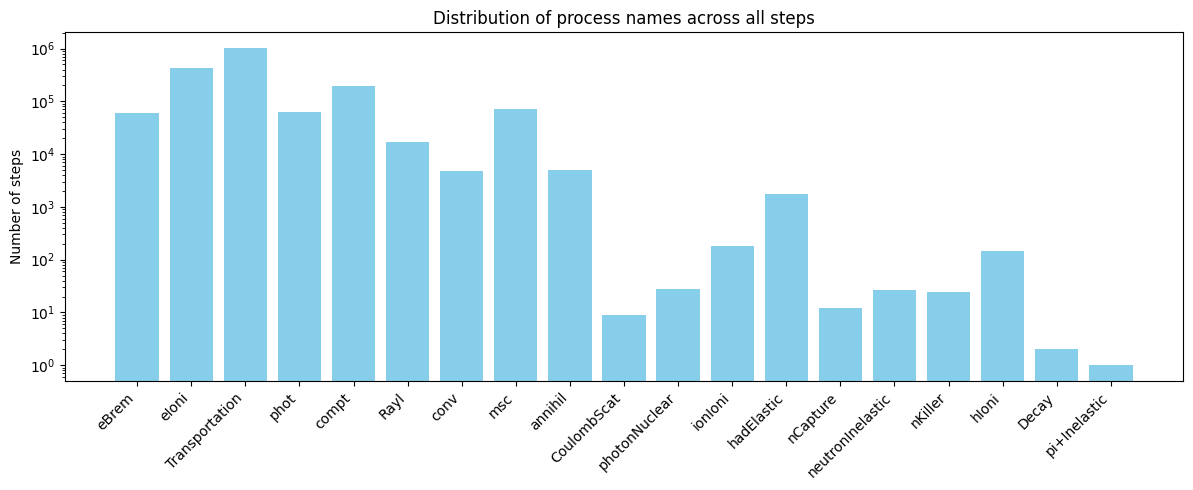

In [3]:
# Read stepProcessNames
step_proc = tree["step_proc"].array(library="np")

# Flatten all process names across all events
all_procs = []
for ev in step_proc:
    all_procs.extend(ev.tolist())  # convert each STLVector to Python list and flatten

# Count occurrences of each process
proc_counts = Counter(all_procs)
print(proc_counts)  # optional: see counts

# Plot all process names
processes = list(proc_counts.keys())
counts = list(proc_counts.values())

plt.figure(figsize=(12,5))
plt.bar(processes, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of steps")
plt.title("Distribution of process names across all steps")
plt.tight_layout()
plt.yscale("log")
plt.show()

In [6]:
E = tree["E"].array(library="np")
finalE = tree["finalE"].array(library="np")
totalEdep = tree["totalEdep"].array(library="np")

x = tree["x"].array(library="np")
y = tree["y"].array(library="np")
z = tree["z"].array(library="np")
finalx = tree["finalX"].array(library="np")
finaly = tree["finalY"].array(library="np")
finalz = tree["finalZ"].array(library="np")

px = tree["px"].array(library="np")
py = tree["py"].array(library="np")
pz = tree["pz"].array(library="np")
finalpx = tree["finalPx"].array(library="np")
finalpy = tree["finalPy"].array(library="np")
finalpz = tree["finalPz"].array(library="np")

costh = tree["costh"].array(library="np")
finalcosth = tree["finalCosth"].array(library="np")

nSecondaries = tree["nSecondaries"].array(library="np")
secFirstZ = tree["secStartZ"].array(library="np")
secLastZ = tree["secEndZ"].array(library="np")
# Example: compute cos(theta) from px, py, pz

sectotalE = tree["secTotalE"].array(library="np")


nGamma      = tree["nGamma"].array(library="np")
nElectron   = tree["nElectron"].array(library="np")
nPositron   = tree["nPositron"].array(library="np")
nProton     = tree["nProtonSec"].array(library="np")
nNeutron    = tree["nNeutron"].array(library="np")
nPionPlus   = tree["nPionPlus"].array(library="np")
nPionMinus  = tree["nPionMinus"].array(library="np")
nPionZero   = tree["nPionZero"].array(library="np")
nMuonPlus  = tree["nMuonPlus"].array(library="np")
nMuonMinus = tree["nMuonMinus"].array(library="np")
nKaonPlus  = tree["nKaonPlus"].array(library="np")
nKaonMinus = tree["nKaonMinus"].array(library="np")
nKaonZero = tree["nKaonZero"].array(library="np")
nKaonZeroL = tree["nKaonZeroL"].array(library="np")
nKaonZeroS = tree["nKaonZeroS"].array(library="np")

nCompt   = tree["nCompton"].array(library="np")
nDecay   = tree["nDecay"].array(library="np")

nPP = tree["nPairProd"].array(library="np")
nAnni = tree["nAnnihilation"].array(library="np")
nBrem = tree["nBremsstrahlung"].array(library="np")
nIon = tree["nIonisation"].array(library="np")
nPE = tree["nnPhotoElectric"].array(library="np")

zs = tree["secEndZ"].array(library="np")
xs = tree["secEndX"].array(library="np")
ys = tree["secEndY"].array(library="np")

# cos(theta) = pz / |p|
p_mag = np.sqrt(px**2 + py**2 + pz**2)
costh = pz / p_mag

# phi = arctangent2(py, px) in radians [0, 2π]
phi = np.arctan2(py, px)
phi[phi < 0] += 2*np.pi  # shift negative angles to [0, 2π]


tgtA = tree["targetA"].array(library="np")
tgtZ = tree["targetZ"].array(library="np")
tgtPDG = tree["targetPDG"].array(library="np")

E_finalTotal = finalE + totalEdep


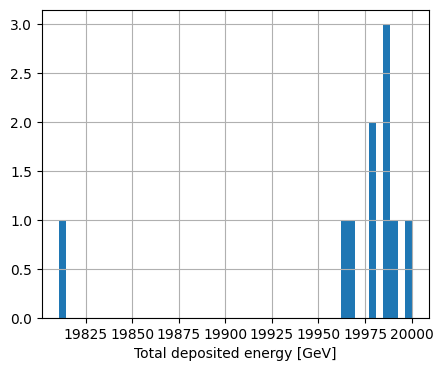

In [9]:
plt.figure(figsize=(5,4))
plt.hist(totalEdep,bins=50)
plt.xlabel("Total deposited energy [GeV]")

#plt.hist(finalE,bins=50)
#plt.xlabel("Final energy [GeV]")

plt.grid(True)
#plt.yscale("log")
plt.show()

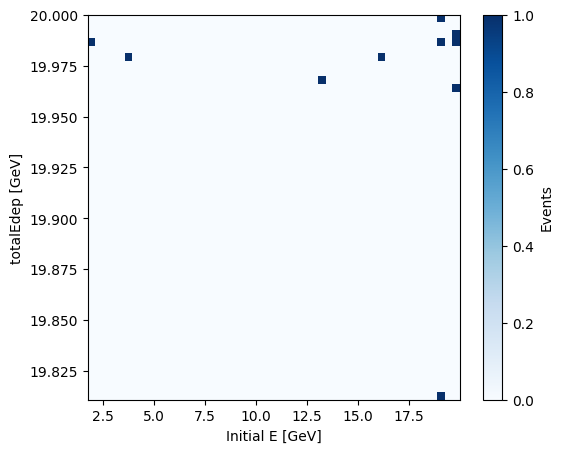

In [10]:

# 2D scatter / density plot
plt.figure(figsize=(6,5))
plt.hist2d(E/1000, E_finalTotal/1000, bins=50, cmap='Blues')
plt.colorbar(label="Events")
#plt.plot([0, max(E)], [0, max(E)], color='red', ls='--', label='E_finalTotal = E')
plt.xlabel("Initial E [GeV]")
plt.ylabel("totalEdep [GeV]")
#plt.ylim(0,30)
#plt.title("Energy conservation check")
#plt.legend()
plt.show()

target A:  [ -1   1  27  40 183 186] target Z:  [-1  1 13 18 74]
PDG  [        -1 1000010010 1000130270 1000180400 1000741830 1000741860]


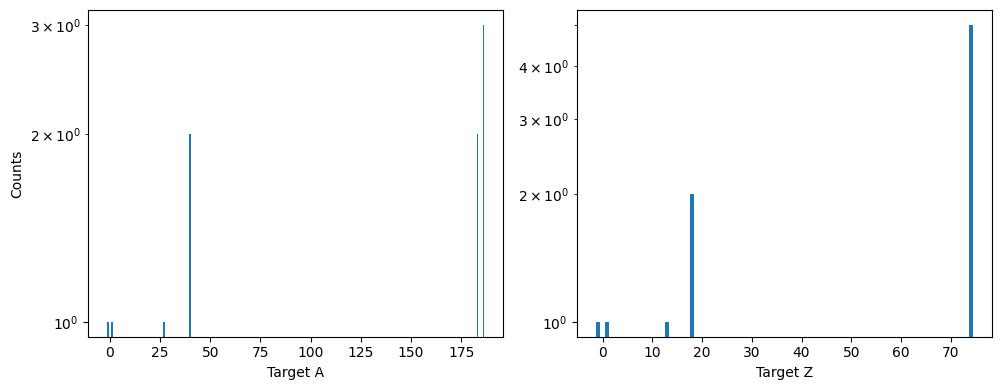

Most common A: 186 count: 3
Most common Z: 74 count: 5
Most common PDG: 1000741860 count: 3


In [14]:
def get_unique(arr):
    vals, counts = np.unique(arr, return_counts=True)
    return vals, counts

# get unique distributions
A_vals, A_counts = get_unique(tgtA)
Z_vals, Z_counts = get_unique(tgtZ)
PDG_vals, PDG_counts = get_unique(tgtPDG)
print("target A: ", A_vals, "target Z: ", Z_vals)
print("PDG ", PDG_vals)
# ---- Plotting ----
plt.figure(figsize=(15,4))


plt.subplot(1,3,1)
plt.bar(A_vals, A_counts)
plt.xlabel("Target A")
plt.ylabel("Counts")
plt.yscale("log")
#plt.xlim(50,75)
#plt.title("Unique targetA")

plt.subplot(1,3,2)
plt.bar(Z_vals, Z_counts)
plt.xlabel("Target Z")
plt.yscale("log")

#plt.title("Unique targetZ")

#plt.subplot(1,3,3)
#plt.bar(PDG_vals, PDG_counts)
#plt.xlabel("Target PDG")
#plt.title("Unique targetPDG")
#plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Find max for A
A_max_idx = np.argmax(A_counts)
A_max_val = A_vals[A_max_idx]
A_max_count = A_counts[A_max_idx]

# Find max for Z
Z_max_idx = np.argmax(Z_counts)
Z_max_val = Z_vals[Z_max_idx]
Z_max_count = Z_counts[Z_max_idx]

# Find max for PDG
PDG_max_idx = np.argmax(PDG_counts)
PDG_max_val = PDG_vals[PDG_max_idx]
PDG_max_count = PDG_counts[PDG_max_idx]

print("Most common A:", A_max_val, "count:", A_max_count)
print("Most common Z:", Z_max_val, "count:", Z_max_count)
print("Most common PDG:", PDG_max_val, "count:", PDG_max_count)

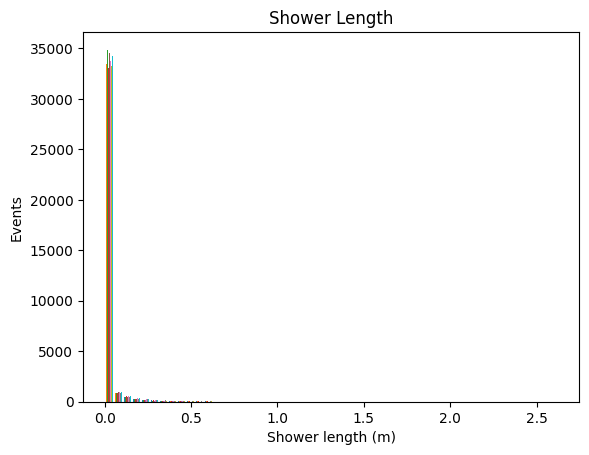

In [18]:
#shower_length = data['secLastZ'] - data['secFirstZ']
shower_length = abs(secLastZ - secFirstZ)

plt.hist(shower_length/1000, bins=50)
plt.xlabel("Shower length (m)")
plt.ylabel("Events")
plt.title("Shower Length")
plt.show()

Text(0.95, 0.95, '$E_{e}$ = 20 GeV')

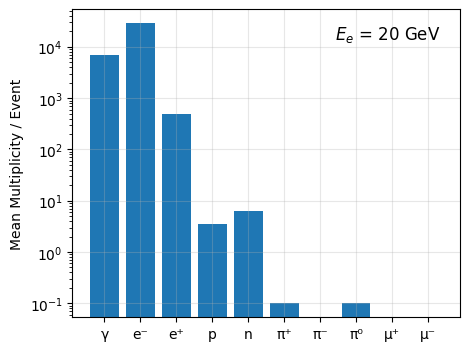

In [20]:
labels = [
    "γ", "e⁻", "e⁺", "p", "n",
    "π⁺", "π⁻", "π⁰",
    "μ⁺", "μ⁻"
]
#labels = [
#    "γ", "e⁻", "e⁺", "p", "n",
#    "π⁺", "π⁻", "π⁰",
#    "K⁺", "K⁻", "K⁰", "K⁰L", "K⁰S",
#    "μ⁺", "μ⁻"
#]
means = [
    np.mean(nGamma),
    np.mean(nElectron),
    np.mean(nPositron),
    np.mean(nProton),
    np.mean(nNeutron),
    np.mean(nPionPlus),
    np.mean(nPionMinus),
    np.mean(nPionZero),
    #np.mean(nKaonPlus),
    ##np.mean(nKaonMinus),
    #np.mean(nKaonZero),
    #np.mean(nKaonZeroL),
    #np.mean(nKaonZeroS),
    np.mean(nMuonPlus),
    np.mean(nMuonMinus)
]

plt.figure(figsize=(5,4))
plt.bar(labels, means)
plt.ylabel("Mean Multiplicity / Event")
#plt.title("Average Secondary Particle Production")
plt.grid(alpha=0.3)
plt.yscale("log")
# Add text
plt.text(0.95, 0.95, "$E_{e}$ = 20 GeV", 
         horizontalalignment='right', verticalalignment='top',
         transform=plt.gca().transAxes, fontsize=12)

#plt.text(0.95, 0.95, "$E_{ν_{e}}$ = 20 GeV", 
 #        horizontalalignment='right', verticalalignment='top',
  #       transform=plt.gca().transAxes, fontsize=12)


In [21]:
print("p mean:", np.mean(nProton), " max:", np.max(nProton))
print("n mean:", np.mean(nNeutron), " max:", np.max(nNeutron))

print("π+ mean:", np.mean(nPionPlus), " max:", np.max(nPionPlus))
print("π- mean:", np.mean(nPionMinus), " max:", np.max(nPionMinus))
print("π0 mean:", np.mean(nPionZero), " max:", np.max(nPionZero))

p mean: 3.5  max: 18
n mean: 6.3  max: 27
π+ mean: 0.1  max: 1
π- mean: 0.0  max: 0
π0 mean: 0.1  max: 1


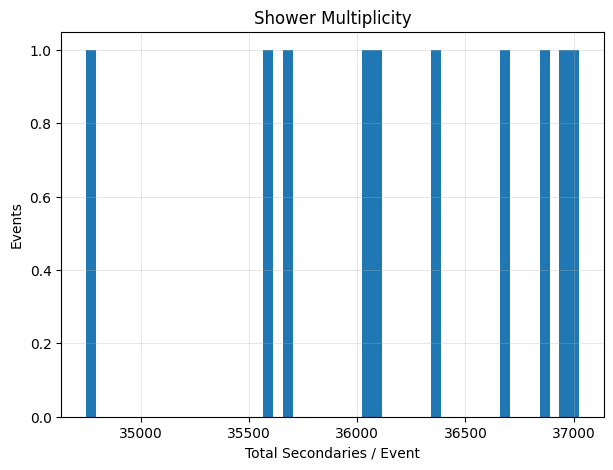

In [22]:
total_sec = (
    nGamma + nElectron + nPositron +
    nProton + nNeutron +
    nPionPlus + nPionMinus + nPionZero
)

plt.figure(figsize=(7,5))
plt.hist(total_sec, bins=50)
plt.xlabel("Total Secondaries / Event")
plt.ylabel("Events")
plt.title("Shower Multiplicity")
plt.grid(alpha=0.3)
plt.show()

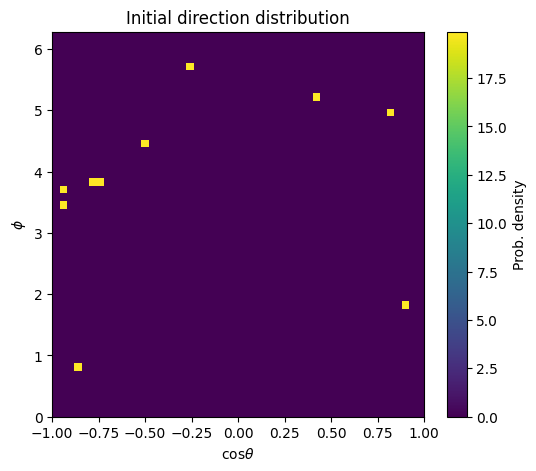

In [23]:
# 2D histogram cos(theta) vs phi
plt.figure(figsize=(6,5))
plt.hist2d(costh, phi, bins=[50,50], range=[[-1,1],[0,2*np.pi]], cmap="viridis", density=True)
plt.xlabel("cos$\\theta$")
plt.ylabel("$\\phi$")
plt.title("Initial direction distribution")
plt.colorbar(label="Prob. density")
plt.show()

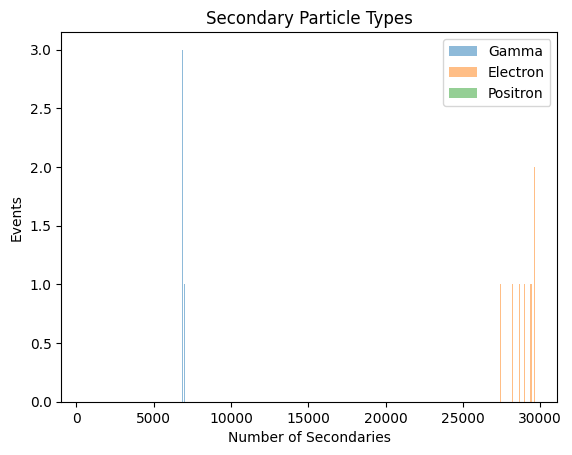

In [24]:
# --- 5. Secondary particle counts ---
plt.hist(data["nGamma"], bins=20, alpha=0.5, label="Gamma")
plt.hist(data["nElectron"], bins=50, alpha=0.5, label="Electron")
plt.hist(data["nPositron"],  bins=20, alpha=0.5, label="Positron")
plt.xlabel("Number of Secondaries")
plt.ylabel("Events")
plt.legend()
plt.title("Secondary Particle Types")
plt.show()


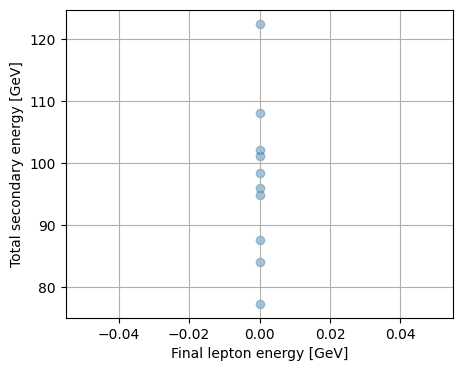

In [25]:
# --- 6. Secondary energy ---
#plt.hist(data["secTotalE"]/1000, bins=50)
##plt.xlabel("Total Secondary Energy (GeV)")
#plt.ylabel("Events")
#plt.title("Total Energy of Secondaries")
#plt.yscale("log")
#plt.show()

# Optional: correlate with final lepton energy
plt.figure(figsize=(5,4))
plt.scatter(finalE/1000, sectotalE/1000, alpha=0.4)
plt.xlabel("Final lepton energy [GeV]")
plt.ylabel("Total secondary energy [GeV]")
plt.grid(True)
plt.show()


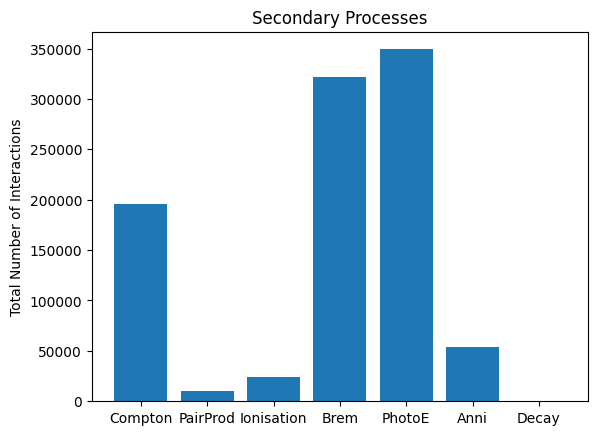

In [26]:

plt.bar(
    ["Compton","PairProd","Ionisation","Brem","PhotoE","Anni","Decay"],
     [np.sum(data["nCompton"]), np.sum(data["nPairProd"]), np.sum(data["nIonisation"]), np.sum(data["nBremsstrahlung"]), np.sum(data["nnPhotoElectric"]), np.sum(data["nAnnihilation"]),np.sum(data["nDecay"]) ]
)

plt.ylabel("Total Number of Interactions")
plt.title("Secondary Processes")
plt.show()

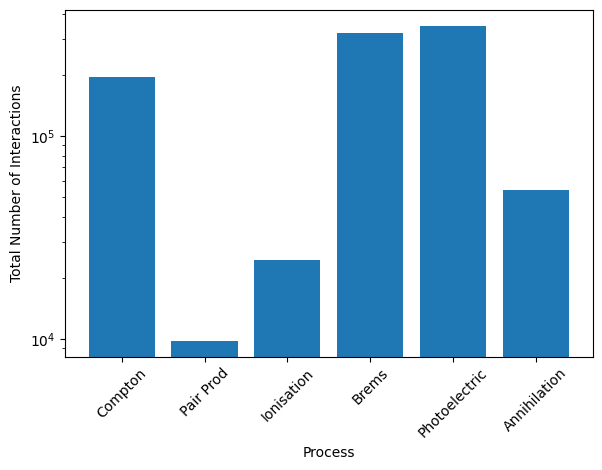

In [27]:

# Sum over all events
values = [
    np.sum(nCompt),
    np.sum(nPP),
    np.sum(nIon),
    np.sum(nBrem),
    np.sum(nPE),
    np.sum(nAnni)
]

labels = [
    "Compton",
    "Pair Prod",
    "Ionisation",
    "Brems",
    "Photoelectric",
    "Annihilation"
]

# Bar plot
plt.bar(labels, values)

plt.ylabel("Total Number of Interactions")
plt.xlabel("Process")
#plt.title("Electromagnetic Processes (1 GeV e⁻)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.yscale("log")

plt.show()
